# Intrusion Detection System — Modelling (Part 3: Binary, MLP from scratch)
### Dataset: CICIDS-2017  ·  Runs on **Kaggle**

**Scratch-model #2 of the project's *"at least 2 from-scratch"* requirement.** A multi-layer perceptron implemented in pure NumPy — forward pass, ReLU activations, dropout, He-initialised weights, **hand-derived backpropagation**, mini-batch GD, L2 regularisation, weighted loss for class imbalance. No `sklearn`/`torch`/`tf` for the model itself.

**Architecture:** input(47) → Dense → ReLU → Dropout → Dense → ReLU → Dropout → Dense → Sigmoid. Two hidden layers; layer widths are a tuned hyperparameter.

**Why a second model?** The from-scratch logistic regression scored **F1 = 0.9052** on this binary task. It plateaus because it's linear — every prediction is a weighted sum of features. An MLP can model non-linear feature interactions, which is exactly where intrusion detection benefits (e.g. an attack might be characterised by `large packets AND short IAT AND no init_win`, a conjunction logistic regression can't represent directly).

**This notebook:**
| # | Section | Notes |
|---|---------|-------|
| 1 | Setup | Kaggle paths, report helpers |
| 2 | Data journey + load | both training strategies (real + SMOTE), shared test |
| 3 | `MLPScratch` from scratch | forward, ReLU, dropout, He init, backprop, mini-batch GD, L2, class weights |
| 4 | Smoke test | sanity-check the implementation learns at all |
| 5 | Grid search | hidden sizes × learning rate × dropout × L2 (ranked by val F1) |
| 6 | SMOTE vs class-weighting | retrain best config both ways |
| 7 | **MLP vs Logistic Regression** | the headline comparison — does non-linearity actually help? |
| 8 | Save | weights + metrics + figures |

**Kaggle setup:** same FeatureSelection output dataset as the LR notebooks — `train_selected.parquet`, `train_binary_smote_selected.parquet`, `test_selected.parquet`, `selected_features.json`. Set `IN_DIR` to its mount path.

**LR-binary results to beat:** F1 = 0.9052, ROC-AUC = 0.9932, precision = 0.8501, recall = 0.9680.

## 1. Imports, Config & Report Helpers

In [1]:
import os, json, time, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             precision_recall_curve, classification_report)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Kaggle paths ───────────────────────────────────────────────────
# IN_DIR : Kaggle Dataset / Notebook Output holding FeatureSelection.ipynb results
#   ----> EDIT to match the mount path shown in the Kaggle 'Input' panel.
IN_DIR      = '/kaggle/input/datasets/hanzlahmunir/fs-output'
OUT_DIR     = '/kaggle/working'
FIGURES_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── report helpers ─────────────────────────────────────────────────
_report_lines = []

def _log(text=''):
    _report_lines.append(str(text))
    print(text)

def _savefig(name, fig=None):
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt).savefig(path, dpi=130, bbox_inches='tight')
    return path

def write_report():
    path = os.path.join(OUT_DIR, 'Modeling_Binary_MLP_Report.txt')
    with open(path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(_report_lines))
    print(f'\nReport saved -> {path}')

_log('=' * 70)
_log('MODELLING REPORT (BINARY, MLP)  —  CICIDS-2017')
_log('Model : Multi-Layer Perceptron (from scratch, NumPy)')
_log(f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
_log('=' * 70)
print('\nSetup complete.')
print('  Reading from :', IN_DIR)
print('  Writing to   :', OUT_DIR)

MODELLING REPORT (BINARY, MLP)  —  CICIDS-2017
Model : Multi-Layer Perceptron (from scratch, NumPy)
Generated : 2026-05-15 09:43

Setup complete.
  Reading from : /kaggle/input/datasets/hanzlahmunir/fs-output
  Writing to   : /kaggle/working


## 2. Load Data — Both Imbalance Strategies
Same setup as the LR-binary notebook. We use the **same FeatureSelection output dataset** so the LR-vs-MLP comparison in Section 7 is on identical training data.

In [2]:
train_path = os.path.join(IN_DIR, 'train_selected.parquet')
smote_path = os.path.join(IN_DIR, 'train_binary_smote_selected.parquet')
test_path  = os.path.join(IN_DIR, 'test_selected.parquet')
feat_path  = os.path.join(IN_DIR, 'selected_features.json')

for p in [train_path, smote_path, test_path, feat_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f'{p} not found. Set IN_DIR to the Kaggle mount path of your '
            'FeatureSelection output (Input panel on the right).')

with open(feat_path) as f:
    selected_features = json.load(f)['selected_features']

train_df = pd.read_parquet(train_path)
smote_df = pd.read_parquet(smote_path)
test_df  = pd.read_parquet(test_path)

X_train_full = train_df[selected_features].values.astype(np.float32)
y_train_full = train_df['label_binary'].values.astype(np.float32)
X_smote      = smote_df[selected_features].values.astype(np.float32)
y_smote      = smote_df['label_binary'].values.astype(np.float32)
X_test       = test_df[selected_features].values.astype(np.float32)
y_test       = test_df['label_binary'].values.astype(np.float32)

# tuning split from REAL training data — for grid search; test stays untouched
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    random_state=RANDOM_SEED, stratify=y_train_full)

n_features = X_train_full.shape[1]

_log('')
_log('── SECTION 2 : DATA LOADED ────────────────────────────────')
_log(f'  Features used (input dim) : {n_features}')
_log(f'  Real train (strategy A)   : {X_train_full.shape[0]:,} rows')
_log(f'    -> tuning split: train={X_tr.shape[0]:,}  val={X_val.shape[0]:,}')
_log(f'  SMOTE train (strategy B)  : {X_smote.shape[0]:,} rows')
_log(f'  Test (held out, shared)   : {X_test.shape[0]:,} rows')
_log(f'  Real train balance        : BENIGN={int((y_train_full==0).sum()):,}  ATTACK={int((y_train_full==1).sum()):,}')
print('\nDtype: float32 (memory-efficient for the MLP forward/backward pass)')


── SECTION 2 : DATA LOADED ────────────────────────────────
  Features used (input dim) : 47
  Real train (strategy A)   : 2,059,411 rows
    -> tuning split: train=1,647,528  val=411,883
  SMOTE train (strategy B)  : 3,437,418 rows
  Test (held out, shared)   : 514,853 rows
  Real train balance        : BENIGN=1,718,709  ATTACK=340,702

Dtype: float32 (memory-efficient for the MLP forward/backward pass)


## 3. `MLPScratch` — Multi-Layer Perceptron in Pure NumPy
Two hidden layers, ReLU activations, sigmoid output. **All gradients are hand-derived** — no autograd, no `sklearn.neural_network`. The whole forward and backward pass is the kind of thing you'd write on a midterm.

**The architecture.** For input $x \in \mathbb{R}^d$, weights $W_1, W_2, W_3$ and biases $b_1, b_2, b_3$:
$$z_1 = xW_1 + b_1, \quad a_1 = \text{ReLU}(z_1)$$
$$z_2 = a_1 W_2 + b_2, \quad a_2 = \text{ReLU}(z_2)$$
$$z_3 = a_2 W_3 + b_3, \quad \hat y = \sigma(z_3)$$

**Loss.** Weighted binary cross-entropy + L2:
$$\mathcal{L} = -\tfrac{1}{n}\sum w_i\big[y_i\log\hat y_i + (1-y_i)\log(1-\hat y_i)\big] + \tfrac{\lambda}{2n}\big(\lVert W_1\rVert^2 + \lVert W_2\rVert^2 + \lVert W_3\rVert^2\big)$$

**Backprop.** The sigmoid-output + BCE combo gives the clean form $\partial\mathcal{L}/\partial z_3 = (\hat y - y) w_i$. From there, by the chain rule:
$$\nabla W_3 = \tfrac{1}{m} a_2^\top \delta_3 + \tfrac{\lambda}{m} W_3, \qquad \nabla b_3 = \tfrac{1}{m}\textstyle\sum \delta_3$$
$$\delta_2 = (\delta_3 W_3^\top) \odot \mathbb{1}_{z_2>0} \odot \text{mask}_2, \quad \nabla W_2 = \tfrac{1}{m} a_1^\top \delta_2 + \tfrac{\lambda}{m} W_2, \quad \nabla b_2 = \tfrac{1}{m}\textstyle\sum \delta_2$$
$$\delta_1 = (\delta_2 W_2^\top) \odot \mathbb{1}_{z_1>0} \odot \text{mask}_1, \quad \nabla W_1 = \tfrac{1}{m} x^\top \delta_1 + \tfrac{\lambda}{m} W_1, \quad \nabla b_1 = \tfrac{1}{m}\textstyle\sum \delta_1$$

**He initialisation** for ReLU: $W \sim \mathcal{N}(0,\, 2/\text{fan\_in})$. Crucial — Xavier init causes ReLU networks to die in the first few epochs.

**Dropout** (inverted): in training, mask $\sim \text{Bernoulli}(1-p)$ then scale by $1/(1-p)$; in inference, pass through unchanged. This keeps activations' expected magnitude constant between train and test.

**Class weighting:** inverse class frequency, same as the LR notebook — keeps the comparison fair.

In [3]:
class MLPScratch:
    """Binary MLP — pure NumPy. 2 hidden layers, ReLU, dropout, sigmoid out,
    weighted BCE + L2, He init, mini-batch GD."""

    def __init__(self, input_dim, hidden_sizes=(64, 32), lr=0.01, lambda_=0.0,
                 dropout=0.0, batch_size=4096, epochs=30, class_weight=True,
                 random_state=42, verbose=False):
        self.input_dim = input_dim
        self.hidden_sizes = tuple(hidden_sizes)
        self.lr = lr
        self.lambda_ = lambda_
        self.dropout = dropout
        self.batch_size = batch_size
        self.epochs = epochs
        self.class_weight = class_weight
        self.random_state = random_state
        self.verbose = verbose
        self.params = {}                                  # W1,b1, W2,b2, W3,b3
        self.history = {'train_loss': [], 'val_loss': []}

    def _init_params(self):
        rng = np.random.RandomState(self.random_state)
        h1, h2 = self.hidden_sizes
        # He init: std = sqrt(2 / fan_in)
        self.params['W1'] = rng.randn(self.input_dim, h1).astype(np.float32) * np.sqrt(2.0 / self.input_dim)
        self.params['b1'] = np.zeros(h1, dtype=np.float32)
        self.params['W2'] = rng.randn(h1, h2).astype(np.float32) * np.sqrt(2.0 / h1)
        self.params['b2'] = np.zeros(h2, dtype=np.float32)
        self.params['W3'] = rng.randn(h2, 1).astype(np.float32) * np.sqrt(2.0 / h2)
        self.params['b3'] = np.zeros(1, dtype=np.float32)

    @staticmethod
    def _relu(z):
        return np.maximum(0.0, z)

    @staticmethod
    def _sigmoid(z):
        # stable: split positive/negative branches to avoid overflow in exp
        out = np.empty_like(z)
        pos = z >= 0
        out[pos]  = 1.0 / (1.0 + np.exp(-z[pos]))
        ez        = np.exp(z[~pos])
        out[~pos] = ez / (1.0 + ez)
        return out

    def _forward(self, X, training, rng=None):
        p = self.params
        z1 = X @ p['W1'] + p['b1']
        a1 = self._relu(z1)
        if training and self.dropout > 0:
            mask1 = (rng.rand(*a1.shape) >= self.dropout).astype(np.float32) / (1.0 - self.dropout)
            a1 *= mask1
        else:
            mask1 = None

        z2 = a1 @ p['W2'] + p['b2']
        a2 = self._relu(z2)
        if training and self.dropout > 0:
            mask2 = (rng.rand(*a2.shape) >= self.dropout).astype(np.float32) / (1.0 - self.dropout)
            a2 *= mask2
        else:
            mask2 = None

        z3 = a2 @ p['W3'] + p['b3']
        y_hat = self._sigmoid(z3).ravel()
        cache = {'X': X, 'z1': z1, 'a1': a1, 'mask1': mask1,
                 'z2': z2, 'a2': a2, 'mask2': mask2, 'y_hat': y_hat}
        return y_hat, cache

    def _loss(self, X, y, sample_w):
        y_hat, _ = self._forward(X, training=False)
        eps = 1e-12
        bce = -(sample_w * (y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))).mean()
        l2  = (self.lambda_ / (2 * len(y))) * (np.sum(self.params['W1']**2) +
                                                np.sum(self.params['W2']**2) +
                                                np.sum(self.params['W3']**2))
        return float(bce + l2)

    def _backward(self, cache, y, sample_w):
        """Hand-derived gradients for the 2-hidden-layer MLP."""
        p = self.params
        X, a1, a2 = cache['X'], cache['a1'], cache['a2']
        z1, z2     = cache['z1'], cache['z2']
        m = X.shape[0]

        # output layer: BCE + sigmoid -> dL/dz3 = (y_hat - y) * sample_w
        d3 = ((cache['y_hat'] - y) * sample_w).reshape(-1, 1)
        gW3 = (a2.T @ d3) / m + (self.lambda_ / m) * p['W3']
        gb3 = d3.sum(axis=0) / m

        # hidden 2: back-prop through dropout mask then ReLU
        d2 = d3 @ p['W3'].T
        if cache['mask2'] is not None: d2 *= cache['mask2']
        d2 *= (z2 > 0)                # ReLU derivative
        gW2 = (a1.T @ d2) / m + (self.lambda_ / m) * p['W2']
        gb2 = d2.sum(axis=0) / m

        # hidden 1
        d1 = d2 @ p['W2'].T
        if cache['mask1'] is not None: d1 *= cache['mask1']
        d1 *= (z1 > 0)
        gW1 = (X.T @ d1) / m + (self.lambda_ / m) * p['W1']
        gb1 = d1.sum(axis=0) / m

        return {'W1': gW1, 'b1': gb1, 'W2': gW2, 'b2': gb2, 'W3': gW3, 'b3': gb3}

    def fit(self, X, y, X_val=None, y_val=None):
        rng = np.random.RandomState(self.random_state)
        self._init_params()

        # per-sample class weights
        if self.class_weight:
            n_pos, n_neg = (y == 1).sum(), (y == 0).sum()
            w_pos = len(y) / (2.0 * max(n_pos, 1))
            w_neg = len(y) / (2.0 * max(n_neg, 1))
            sw = np.where(y == 1, w_pos, w_neg).astype(np.float32)
        else:
            sw = np.ones(len(y), dtype=np.float32)
        sw_val = np.ones(len(y_val), dtype=np.float32) if y_val is not None else None

        n = len(y)
        for epoch in range(self.epochs):
            idx = rng.permutation(n)
            for start in range(0, n, self.batch_size):
                bi = idx[start:start + self.batch_size]
                Xb, yb, swb = X[bi], y[bi], sw[bi]
                _, cache = self._forward(Xb, training=True, rng=rng)
                grads = self._backward(cache, yb, swb)
                for k in self.params:
                    self.params[k] -= self.lr * grads[k]
            self.history['train_loss'].append(self._loss(X, y, sw))
            if X_val is not None:
                self.history['val_loss'].append(self._loss(X_val, y_val, sw_val))
            if self.verbose:
                msg = f'  epoch {epoch+1:3}/{self.epochs}  train={self.history["train_loss"][-1]:.4f}'
                if X_val is not None:
                    msg += f'  val={self.history["val_loss"][-1]:.4f}'
                print(msg)
        return self

    def predict_proba(self, X):
        y_hat, _ = self._forward(X, training=False)
        return y_hat

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def n_params(self):
        return sum(v.size for v in self.params.values())

print('MLPScratch defined.')
print('  2 hidden layers + ReLU + dropout + sigmoid')
print('  He init, weighted BCE + L2, hand-derived backprop, mini-batch GD')

MLPScratch defined.
  2 hidden layers + ReLU + dropout + sigmoid
  He init, weighted BCE + L2, hand-derived backprop, mini-batch GD


## 4. Smoke Test — Confirm the From-Scratch MLP Learns
Before grid search (which is expensive), train a single small MLP for 15 epochs and check that the loss decreases monotonically. If this fails, there's a bug in the backprop.

  epoch   1/15  train=0.3312  val=0.3559
  epoch   2/15  train=0.2364  val=0.2473
  epoch   3/15  train=0.1911  val=0.1943
  epoch   4/15  train=0.1654  val=0.1661
  epoch   5/15  train=0.1487  val=0.1491
  epoch   6/15  train=0.1369  val=0.1366
  epoch   7/15  train=0.1281  val=0.1264
  epoch   8/15  train=0.1213  val=0.1202
  epoch   9/15  train=0.1158  val=0.1141
  epoch  10/15  train=0.1112  val=0.1090
  epoch  11/15  train=0.1072  val=0.1042
  epoch  12/15  train=0.1037  val=0.1007
  epoch  13/15  train=0.1005  val=0.0978
  epoch  14/15  train=0.0977  val=0.0953
  epoch  15/15  train=0.0950  val=0.0919

── SECTION 4 : MLP SMOKE TEST ─────────────────────────────
  Architecture        : [47 -> 64 -> 32 -> 1]
  Parameter count     : 5,185
  Defaults (lr=0.01, dropout=0.2, lambda=0, batch=8192, epochs=15)
  Validation F1       : 0.9081   (fit took 163.7s)
  Loss : 0.3312 -> 0.0950


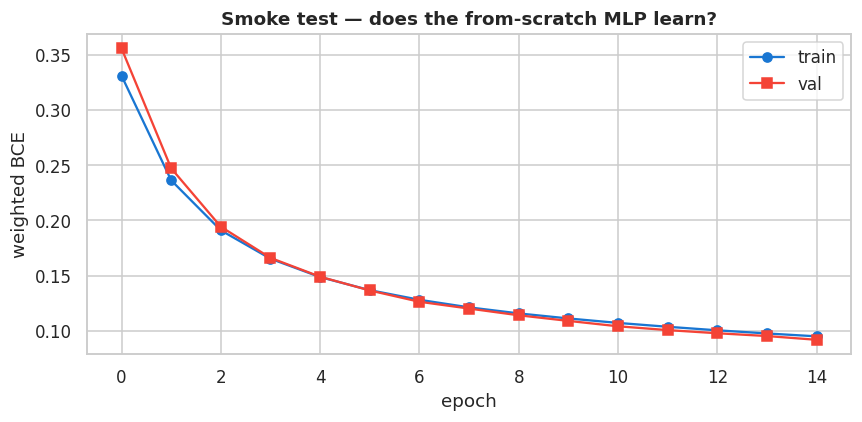

In [4]:
_t = time.time()
_smoke = MLPScratch(input_dim=n_features, hidden_sizes=(64, 32),
                    lr=0.01, lambda_=0.0, dropout=0.2,
                    batch_size=8192, epochs=15, class_weight=True, verbose=True)
_smoke.fit(X_tr, y_tr, X_val, y_val)
_val_f1 = f1_score(y_val, _smoke.predict(X_val))

_log('')
_log('── SECTION 4 : MLP SMOKE TEST ─────────────────────────────')
_log(f'  Architecture        : [{n_features} -> 64 -> 32 -> 1]')
_log(f'  Parameter count     : {_smoke.n_params():,}')
_log(f'  Defaults (lr=0.01, dropout=0.2, lambda=0, batch=8192, epochs=15)')
_log(f'  Validation F1       : {_val_f1:.4f}   (fit took {time.time()-_t:.1f}s)')
_log(f'  Loss : {_smoke.history["train_loss"][0]:.4f} -> {_smoke.history["train_loss"][-1]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(_smoke.history['train_loss'], 'o-', label='train', color='#1976D2')
ax.plot(_smoke.history['val_loss'],  's-', label='val',   color='#F44336')
ax.set_xlabel('epoch'); ax.set_ylabel('weighted BCE')
ax.set_title('Smoke test — does the from-scratch MLP learn?', fontweight='bold')
ax.legend()
plt.tight_layout()
_savefig('01_smoke_test.png', fig)
plt.show()

## 5. Hyperparameter Tuning — Grid Search
MLPs have *more* knobs than LR. To keep the grid manageable we sweep four hyperparameters with small grids:

| Hyperparameter | Grid | What it controls |
|---|---|---|
| `hidden_sizes` | (64,32), (128,64), (256,128) | model capacity |
| `lr` | 0.01, 0.05 | step size |
| `dropout` | 0.0, 0.2 | regularisation |
| `lambda_` | 0.0 | (fixed — dropout is the main regulariser) |

That's 3 × 2 × 2 = **12 fits at 25 epochs each**. Ranked by validation **F1** (same metric the LR notebook used, so the comparison in Section 7 is direct). Tuning is on **real-distribution training data + class weighting**, so we don't bias the search by SMOTE's synthetic rows. Best config is retrained both ways in Section 6.

*(`lr=0.5` is way too high for an MLP — would diverge. MLPs need smaller learning rates than LR because each layer's gradients are products of many terms.)*

In [5]:
param_grid = {
    'hidden_sizes': [(64, 32), (128, 64), (256, 128)],
    'lr':           [0.01, 0.05],
    'dropout':      [0.0, 0.2],
    'lambda_':      [0.0],
}
GRID_EPOCHS = 25
BATCH_SIZE  = 4096

results, histories = [], {}

n_fits = (len(param_grid['hidden_sizes']) * len(param_grid['lr']) *
          len(param_grid['dropout']) * len(param_grid['lambda_']))
_log('')
_log('── SECTION 5 : GRID SEARCH (ranked by validation F1) ──────')
_log(f'  Grid: {n_fits} fits at {GRID_EPOCHS} epochs each, batch_size={BATCH_SIZE}')

t_all = time.time()
for hs in param_grid['hidden_sizes']:
    for lr in param_grid['lr']:
        for dr in param_grid['dropout']:
            for lam in param_grid['lambda_']:
                t0 = time.time()
                model = MLPScratch(input_dim=n_features, hidden_sizes=hs,
                                   lr=lr, lambda_=lam, dropout=dr,
                                   batch_size=BATCH_SIZE, epochs=GRID_EPOCHS,
                                   class_weight=True, random_state=RANDOM_SEED)
                model.fit(X_tr, y_tr, X_val, y_val)
                yv      = model.predict(X_val)
                yv_prob = model.predict_proba(X_val)
                row = {
                    'hidden_sizes': str(hs), 'lr': lr, 'dropout': dr, 'lambda_': lam,
                    'val_f1':        f1_score(y_val, yv),
                    'val_precision': precision_score(y_val, yv),
                    'val_recall':    recall_score(y_val, yv),
                    'val_accuracy':  accuracy_score(y_val, yv),
                    'val_auc':       roc_auc_score(y_val, yv_prob),
                    'final_loss':    model.history['train_loss'][-1],
                    'params':        model.n_params(),
                    'fit_seconds':   time.time() - t0,
                }
                results.append(row)
                histories[(str(hs), lr, dr)] = model.history
                _log(f'  hs={str(hs):<11} lr={lr:<5} dropout={dr:<4} -> '
                     f'F1={row["val_f1"]:.4f}  AUC={row["val_auc"]:.4f}  ({row["fit_seconds"]:.1f}s)')

results_df = pd.DataFrame(results).sort_values('val_f1', ascending=False).reset_index(drop=True)
_log('')
_log(f'  Total grid-search time : {time.time()-t_all:.1f}s')
_log('  Results (sorted by validation F1):')
_log(results_df.to_string(index=False))
display(results_df)

best = results_df.iloc[0]
best_hs = eval(best.hidden_sizes)
_log('')
_log(f'  BEST CONFIG: hidden_sizes={best_hs}, lr={best.lr}, dropout={best.dropout}')
_log(f'              val F1={best.val_f1:.4f}  val AUC={best.val_auc:.4f}  '
     f'({best.params:,} params)')


── SECTION 5 : GRID SEARCH (ranked by validation F1) ──────
  Grid: 12 fits at 25 epochs each, batch_size=4096
  hs=(64, 32)    lr=0.01  dropout=0.0  -> F1=0.9690  AUC=0.9988  (179.8s)
  hs=(64, 32)    lr=0.01  dropout=0.2  -> F1=0.9545  AUC=0.9979  (273.1s)
  hs=(64, 32)    lr=0.05  dropout=0.0  -> F1=0.9882  AUC=0.9997  (179.2s)
  hs=(64, 32)    lr=0.05  dropout=0.2  -> F1=0.9840  AUC=0.9996  (274.8s)
  hs=(128, 64)   lr=0.01  dropout=0.0  -> F1=0.9756  AUC=0.9991  (327.0s)
  hs=(128, 64)   lr=0.01  dropout=0.2  -> F1=0.9607  AUC=0.9984  (518.0s)
  hs=(128, 64)   lr=0.05  dropout=0.0  -> F1=0.9887  AUC=0.9998  (328.6s)
  hs=(128, 64)   lr=0.05  dropout=0.2  -> F1=0.9829  AUC=0.9996  (520.7s)
  hs=(256, 128)  lr=0.01  dropout=0.0  -> F1=0.9805  AUC=0.9994  (717.9s)
  hs=(256, 128)  lr=0.01  dropout=0.2  -> F1=0.9638  AUC=0.9989  (1098.3s)
  hs=(256, 128)  lr=0.05  dropout=0.0  -> F1=0.9904  AUC=0.9998  (729.1s)
  hs=(256, 128)  lr=0.05  dropout=0.2  -> F1=0.9853  AUC=0.9997  (1107.9s

,hidden_sizes,lr,dropout,lambda_,val_f1,val_precision,val_recall,val_accuracy,val_auc,final_loss,params,fit_seconds
0,"(256, 128)",0.0500,0.0000,0.0000,0.9904,0.9865,0.9943,0.9968,0.9998,0.0140,45313,729.0554
1,"(128, 64)",0.0500,0.0000,0.0000,0.9887,0.9837,0.9938,0.9963,0.9998,0.0156,14465,328.6247
2,"(64, 32)",0.0500,0.0000,0.0000,0.9882,0.9831,0.9933,0.9961,0.9997,0.0165,5185,179.2131
3,"(256, 128)",0.0500,0.2000,0.0000,0.9853,0.9774,0.9934,0.9951,0.9997,0.0192,45313,1107.9244
4,"(64, 32)",0.0500,0.2000,0.0000,0.9840,0.9777,0.9905,0.9947,0.9996,0.0229,5185,274.7684
5,"(128, 64)",0.0500,0.2000,0.0000,0.9829,0.9747,0.9913,0.9943,0.9996,0.0224,14465,520.6765
6,"(256, 128)",0.0100,0.0000,0.0000,0.9805,0.9717,0.9895,0.9935,0.9994,0.0292,45313,717.9330
7,"(128, 64)",0.0100,0.0000,0.0000,0.9756,0.9640,0.9875,0.9918,0.9991,0.0357,14465,326.9537
8,"(64, 32)",0.0100,0.0000,0.0000,0.9690,0.9514,0.9872,0.9895,0.9988,0.0408,5185,179.8420
9,"(256, 128)",0.0100,0.2000,0.0000,0.9638,0.9415,0.9871,0.9877,0.9989,0.0419,45313,1098.2573



  BEST CONFIG: hidden_sizes=(256, 128), lr=0.05, dropout=0.0
              val F1=0.9904  val AUC=0.9998  (45,313 params)


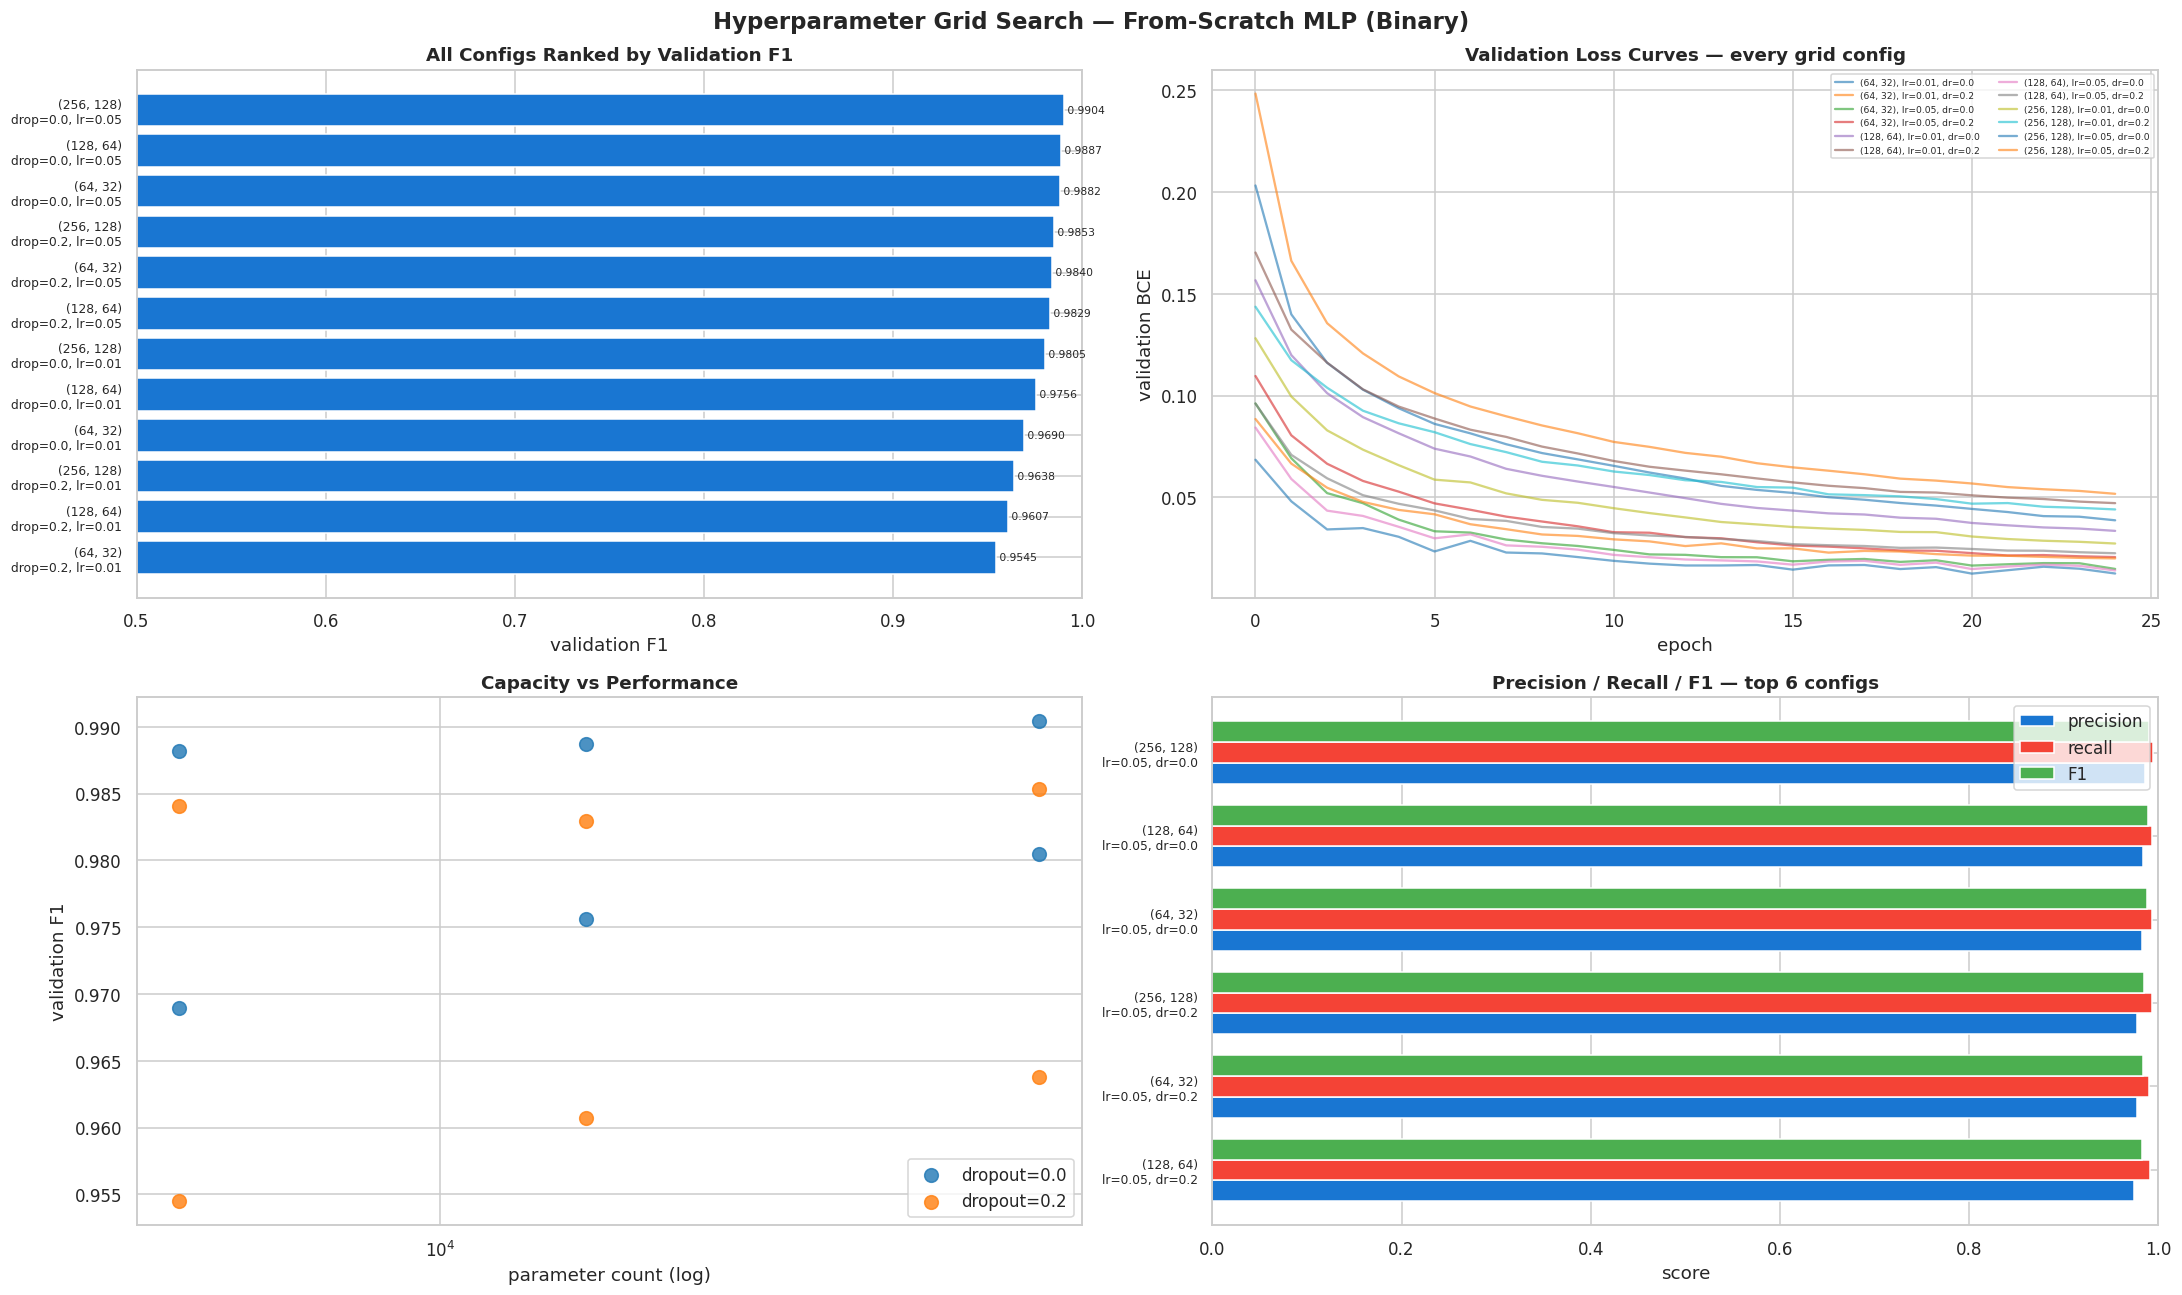

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# (a) F1 grouped by architecture × dropout, side-by-side per learning rate
ax = axes[0, 0]
for_plot = results_df.copy()
for_plot['config'] = (for_plot['hidden_sizes'].astype(str) + '\ndrop=' +
                     for_plot['dropout'].astype(str) + ', lr=' +
                     for_plot['lr'].astype(str))
for_plot = for_plot.sort_values('val_f1')
ax.barh(for_plot['config'], for_plot['val_f1'], color='#1976D2')
ax.set_xlabel('validation F1'); ax.set_xlim(0.5, 1.0)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('All Configs Ranked by Validation F1', fontweight='bold')
for i, v in enumerate(for_plot['val_f1']):
    ax.text(v, i, f' {v:.4f}', va='center', fontsize=7)

# (b) loss curves
ax = axes[0, 1]
for (hs, lr, dr), hist in histories.items():
    ax.plot(hist['val_loss'], alpha=0.6, label=f'{hs}, lr={lr}, dr={dr}')
ax.set_xlabel('epoch'); ax.set_ylabel('validation BCE')
ax.set_title('Validation Loss Curves — every grid config', fontweight='bold')
ax.legend(fontsize=6, ncol=2)

# (c) F1 vs parameter count — does bigger help?
ax = axes[1, 0]
for dr in param_grid['dropout']:
    sub = results_df[results_df['dropout'] == dr]
    ax.scatter(sub['params'], sub['val_f1'], s=80, alpha=0.8,
               label=f'dropout={dr}')
ax.set_xscale('log')
ax.set_xlabel('parameter count (log)'); ax.set_ylabel('validation F1')
ax.set_title('Capacity vs Performance', fontweight='bold')
ax.legend()

# (d) precision / recall / F1 bars for the top configs
ax = axes[1, 1]
top = results_df.head(6).iloc[::-1]
yy = np.arange(len(top))
ax.barh(yy - 0.25, top['val_precision'], 0.25, label='precision', color='#1976D2')
ax.barh(yy,        top['val_recall'],    0.25, label='recall',    color='#F44336')
ax.barh(yy + 0.25, top['val_f1'],        0.25, label='F1',        color='#4CAF50')
labels = [f'{r.hidden_sizes}\nlr={r.lr}, dr={r.dropout}' for r in top.itertuples()]
ax.set_yticks(yy); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('score'); ax.set_xlim(0, 1)
ax.set_title('Precision / Recall / F1 — top 6 configs', fontweight='bold')
ax.legend()

plt.suptitle('Hyperparameter Grid Search — From-Scratch MLP (Binary)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
_savefig('02_grid_search.png', fig)
plt.show()

## 6. SMOTE vs Class-Weighting — Final Models
Same comparison structure as the LR notebook. Take the best config from Section 5 and train it **two ways**, evaluate both on the held-out test set.

Recall: in LR-binary the strategies tied at F1 ≈ 0.9052. The interesting question here is whether **adding non-linearity changes that result**. If the MLP can model rare-class structure better, SMOTE's synthetic samples might give it more useful signal than class-weighting does.

In [7]:
best_hs    = eval(best.hidden_sizes)
best_lr    = float(best.lr)
best_drop  = float(best.dropout)
best_lam   = float(best.lambda_)
FINAL_EPOCHS = 50

def evaluate(model, X, y):
    prob = model.predict_proba(X)
    pred = model.predict(X)
    return {
        'accuracy':  accuracy_score(y, pred),
        'precision': precision_score(y, pred),
        'recall':    recall_score(y, pred),
        'f1':        f1_score(y, pred),
        'roc_auc':   roc_auc_score(y, prob),
    }, pred, prob

_log('')
_log('── SECTION 6 : FINAL MLP MODELS — STRATEGY A vs B ─────────')
_log(f'  Best config: hidden={best_hs}, lr={best_lr}, dropout={best_drop}, '
     f'lambda={best_lam}, epochs={FINAL_EPOCHS}, batch={BATCH_SIZE}')

# A : real data + class weighting
_log('')
_log('  [A] Class weighting — training on real-distribution data ...')
t0 = time.time()
mlp_A = MLPScratch(input_dim=n_features, hidden_sizes=best_hs, lr=best_lr,
                   lambda_=best_lam, dropout=best_drop, batch_size=BATCH_SIZE,
                   epochs=FINAL_EPOCHS, class_weight=True, random_state=RANDOM_SEED)
mlp_A.fit(X_train_full, y_train_full, X_test, y_test)
metrics_A, pred_A, prob_A = evaluate(mlp_A, X_test, y_test)
_log(f'      done in {time.time()-t0:.1f}s')

# B : SMOTE data, no class weighting
_log('  [B] SMOTE — training on synthetically balanced data ...')
t0 = time.time()
mlp_B = MLPScratch(input_dim=n_features, hidden_sizes=best_hs, lr=best_lr,
                   lambda_=best_lam, dropout=best_drop, batch_size=BATCH_SIZE,
                   epochs=FINAL_EPOCHS, class_weight=False, random_state=RANDOM_SEED)
mlp_B.fit(X_smote, y_smote, X_test, y_test)
metrics_B, pred_B, prob_B = evaluate(mlp_B, X_test, y_test)
_log(f'      done in {time.time()-t0:.1f}s')

cmp_df = pd.DataFrame({'A_class_weight': metrics_A, 'B_smote': metrics_B})
cmp_df['difference'] = cmp_df['B_smote'] - cmp_df['A_class_weight']
cmp_df['winner'] = np.where(cmp_df['difference'].abs() < 1e-4, 'tie',
                            np.where(cmp_df['difference'] > 0, 'B_smote', 'A_class_weight'))

_log('')
_log('  TEST-SET COMPARISON (real-world distribution):')
_log(cmp_df.to_string())
display(cmp_df)

f1_A_mlp, f1_B_mlp = metrics_A['f1'], metrics_B['f1']
overall = 'B (SMOTE)' if f1_B_mlp > f1_A_mlp else 'A (class weighting)'
_log('')
_log(f'  Overall winner by F1 : {overall}')
_log(f'    A class-weight F1 = {f1_A_mlp:.4f}  |  B SMOTE F1 = {f1_B_mlp:.4f}')
print(f'\nMLP winner by test F1: {overall}')


── SECTION 6 : FINAL MLP MODELS — STRATEGY A vs B ─────────
  Best config: hidden=(256, 128), lr=0.05, dropout=0.0, lambda=0.0, epochs=50, batch=4096

  [A] Class weighting — training on real-distribution data ...
      done in 1829.4s
  [B] SMOTE — training on synthetically balanced data ...
      done in 3050.9s

  TEST-SET COMPARISON (real-world distribution):
           A_class_weight  B_smote  difference          winner
accuracy           0.9965   0.9975      0.0011         B_smote
precision          0.9823   0.9892      0.0068         B_smote
recall             0.9966   0.9961     -0.0006  A_class_weight
f1                 0.9894   0.9926      0.0032         B_smote
roc_auc            0.9999   0.9999      0.0000             tie


,A_class_weight,B_smote,difference,winner
accuracy,0.9965,0.9975,0.0011,B_smote
precision,0.9823,0.9892,0.0068,B_smote
recall,0.9966,0.9961,-0.0006,A_class_weight
f1,0.9894,0.9926,0.0032,B_smote
roc_auc,0.9999,0.9999,0.0000,tie



  Overall winner by F1 : B (SMOTE)
    A class-weight F1 = 0.9894  |  B SMOTE F1 = 0.9926

MLP winner by test F1: B (SMOTE)


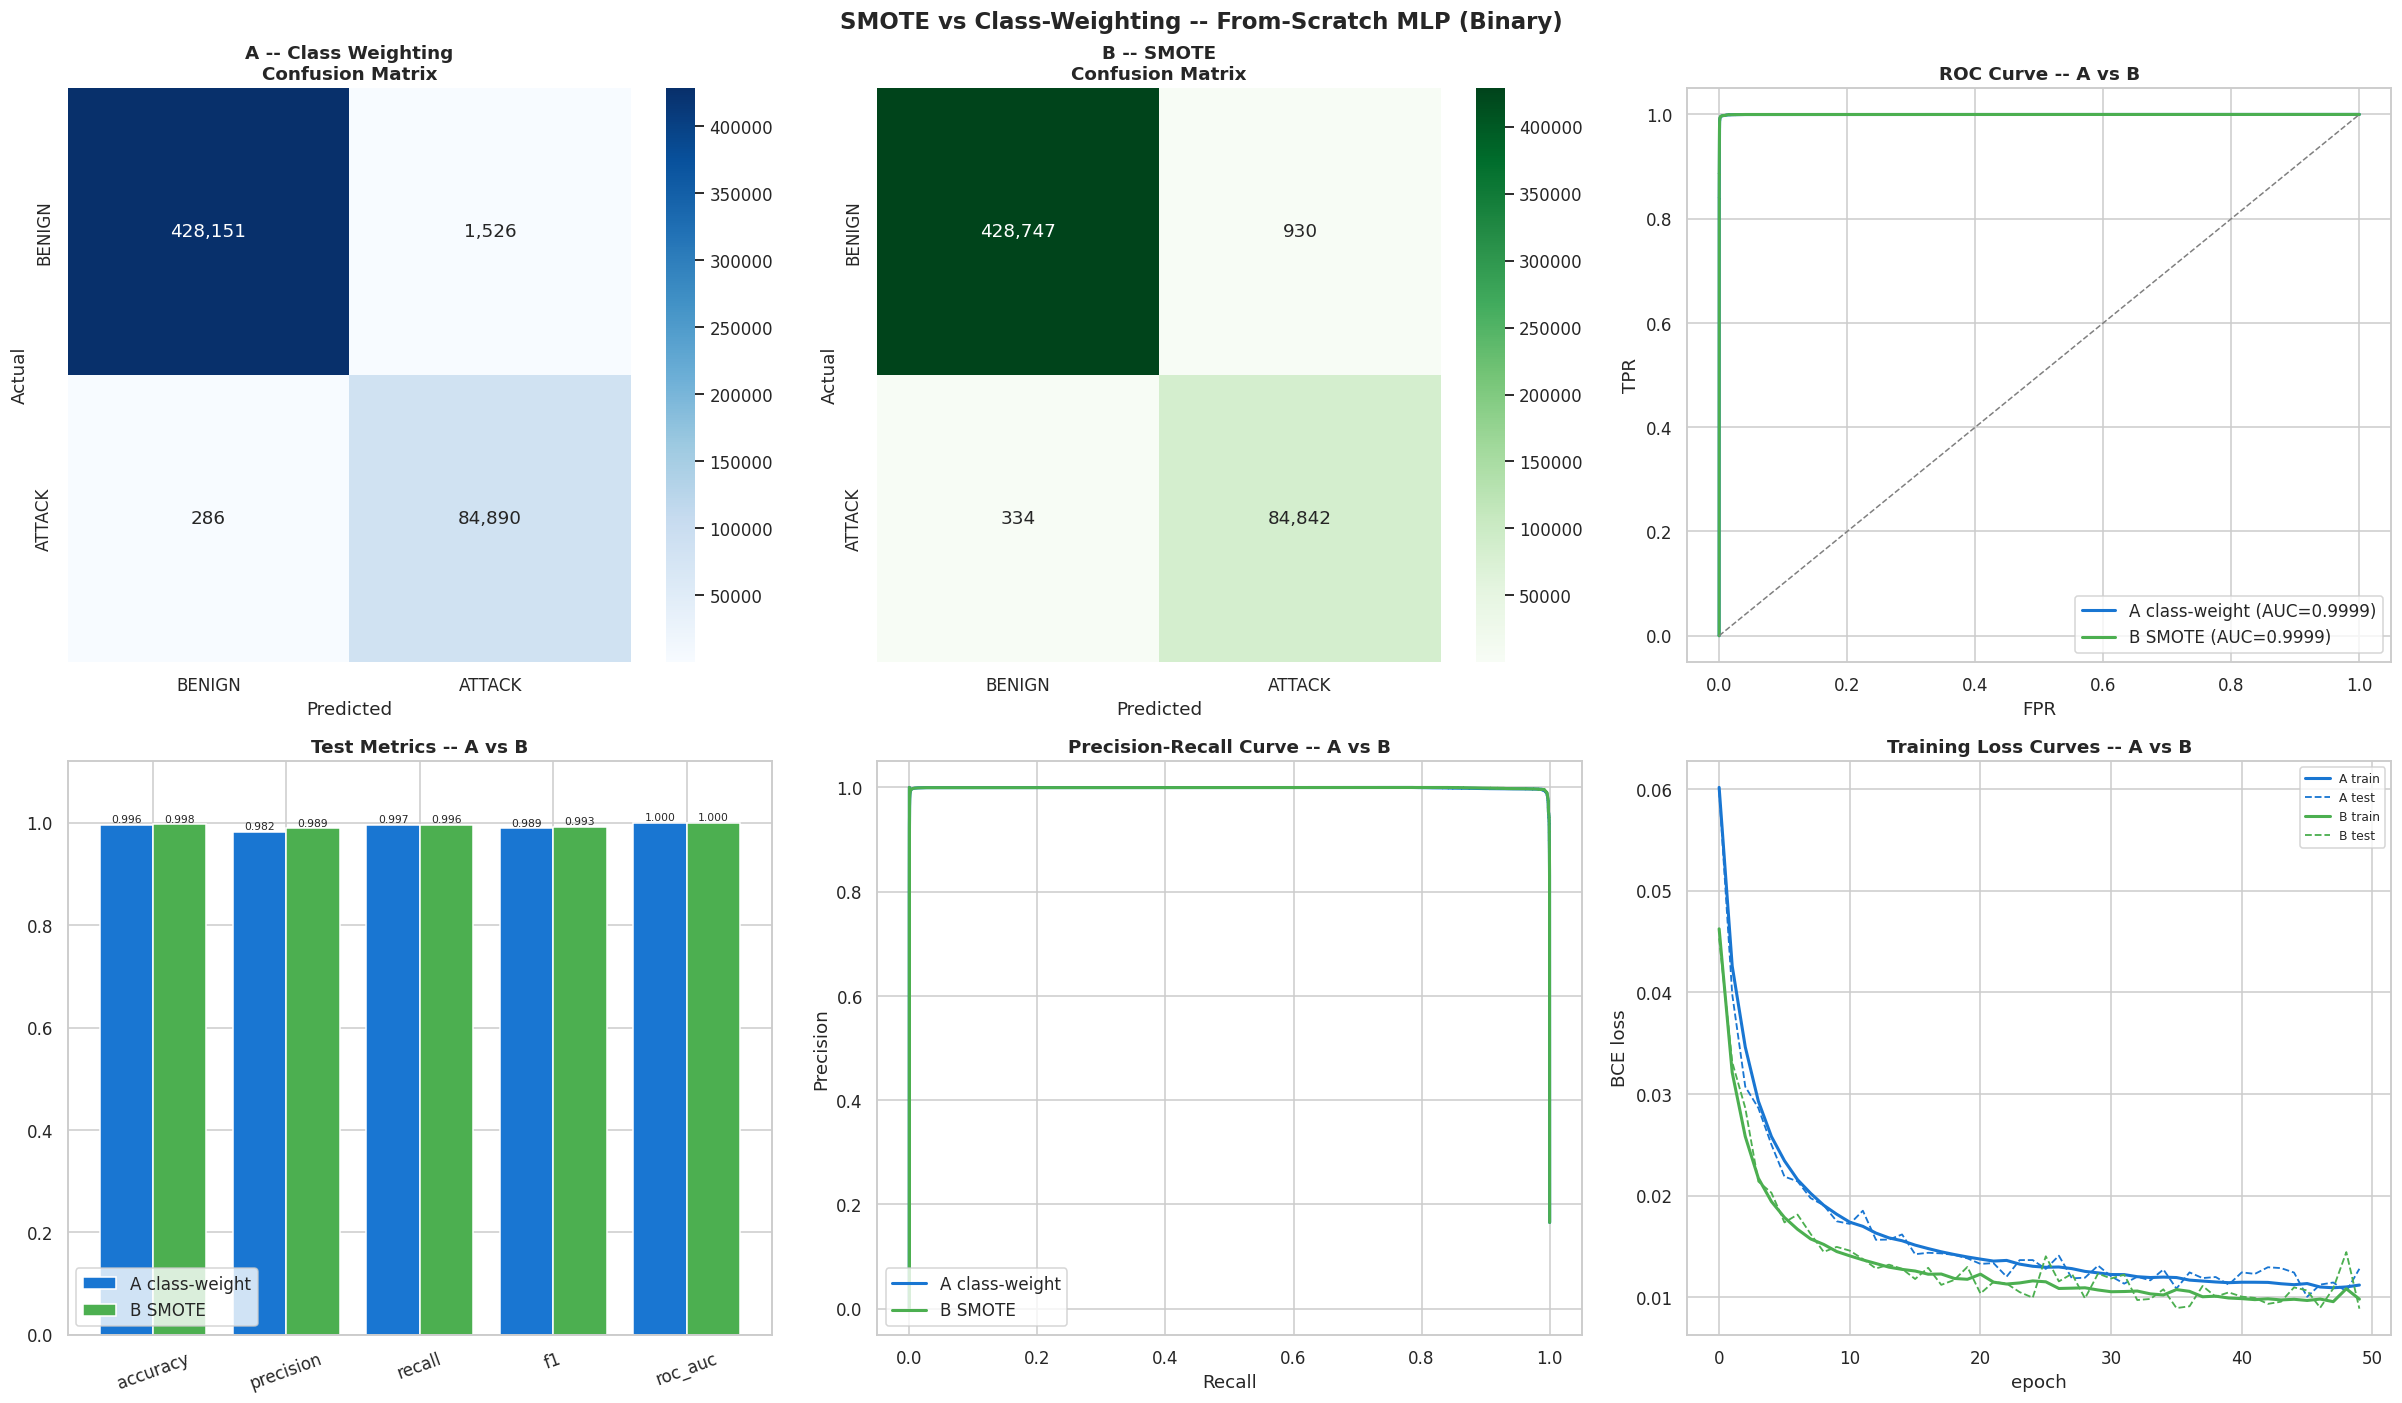

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# confusion matrices
sns.heatmap(confusion_matrix(y_test, pred_A), annot=True, fmt=',d', cmap='Blues',
            ax=axes[0, 0], xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
axes[0, 0].set_title('A -- Class Weighting\nConfusion Matrix', fontweight='bold')
axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, pred_B), annot=True, fmt=',d', cmap='Greens',
            ax=axes[0, 1], xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
axes[0, 1].set_title('B -- SMOTE\nConfusion Matrix', fontweight='bold')
axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')

# ROC
ax = axes[0, 2]
fpr_A, tpr_A, _ = roc_curve(y_test, prob_A)
fpr_B, tpr_B, _ = roc_curve(y_test, prob_B)
auc_A = metrics_A['roc_auc']; auc_B = metrics_B['roc_auc']
ax.plot(fpr_A, tpr_A, color='#1976D2', lw=2, label=f'A class-weight (AUC={auc_A:.4f})')
ax.plot(fpr_B, tpr_B, color='#4CAF50', lw=2, label=f'B SMOTE (AUC={auc_B:.4f})')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve -- A vs B', fontweight='bold'); ax.legend(loc='lower right')

# grouped metric bars
ax = axes[1, 0]
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
xx = np.arange(len(metric_names))
ax.bar(xx - 0.2, [metrics_A[m] for m in metric_names], 0.4,
       label='A class-weight', color='#1976D2')
ax.bar(xx + 0.2, [metrics_B[m] for m in metric_names], 0.4,
       label='B SMOTE', color='#4CAF50')
ax.set_xticks(xx); ax.set_xticklabels(metric_names, rotation=20)
ax.set_ylim(0, 1.12)
ax.set_title('Test Metrics -- A vs B', fontweight='bold'); ax.legend()
for i, m in enumerate(metric_names):
    ax.text(i - 0.2, metrics_A[m], f'{metrics_A[m]:.3f}', ha='center', va='bottom', fontsize=7)
    ax.text(i + 0.2, metrics_B[m], f'{metrics_B[m]:.3f}', ha='center', va='bottom', fontsize=7)

# PR curves
ax = axes[1, 1]
pr_A, rc_A, _ = precision_recall_curve(y_test, prob_A)
pr_B, rc_B, _ = precision_recall_curve(y_test, prob_B)
ax.plot(rc_A, pr_A, color='#1976D2', lw=2, label='A class-weight')
ax.plot(rc_B, pr_B, color='#4CAF50', lw=2, label='B SMOTE')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve -- A vs B', fontweight='bold')
ax.legend(loc='lower left')

# loss curves
ax = axes[1, 2]
ax.plot(mlp_A.history['train_loss'], color='#1976D2', lw=2, label='A train')
ax.plot(mlp_A.history['val_loss'],   color='#1976D2', lw=1.2, ls='--', label='A test')
ax.plot(mlp_B.history['train_loss'], color='#4CAF50', lw=2, label='B train')
ax.plot(mlp_B.history['val_loss'],   color='#4CAF50', lw=1.2, ls='--', label='B test')
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss')
ax.set_title('Training Loss Curves -- A vs B', fontweight='bold'); ax.legend(fontsize=8)

plt.suptitle('SMOTE vs Class-Weighting -- From-Scratch MLP (Binary)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
_savefig('03_smote_vs_classweight.png', fig)
plt.show()

## 7. The Headline — MLP vs Logistic Regression
Both models trained on the **same data**, evaluated on the **same test set**. This is the comparison your report should highlight: *does non-linearity actually help on intrusion detection?*

LR-binary winning numbers (from `Modeling_Binary` notebook): F1 = **0.9052**, AUC = **0.9932**, precision = 0.8501, recall = 0.9680, accuracy = 0.9665.


── SECTION 7 : MLP vs LR (HEADLINE) ───────────────────────
  LR baseline  : class-weighting model from Modeling_Binary.ipynb
  MLP entry    : strategy B_smote  (winner of Section 6)

           LR_scratch  MLP_scratch  delta_MLP_minus_LR
accuracy       0.9665       0.9975              0.0310
precision      0.8501       0.9892              0.1391
recall         0.9680       0.9961              0.0281
f1             0.9052       0.9926              0.0874
roc_auc        0.9932       0.9999              0.0067


,LR_scratch,MLP_scratch,delta_MLP_minus_LR
accuracy,0.9665,0.9975,0.0310
precision,0.8501,0.9892,0.1391
recall,0.9680,0.9961,0.0281
f1,0.9052,0.9926,0.0874
roc_auc,0.9932,0.9999,0.0067



  F1 delta  : +0.0874
  AUC delta : +0.0067


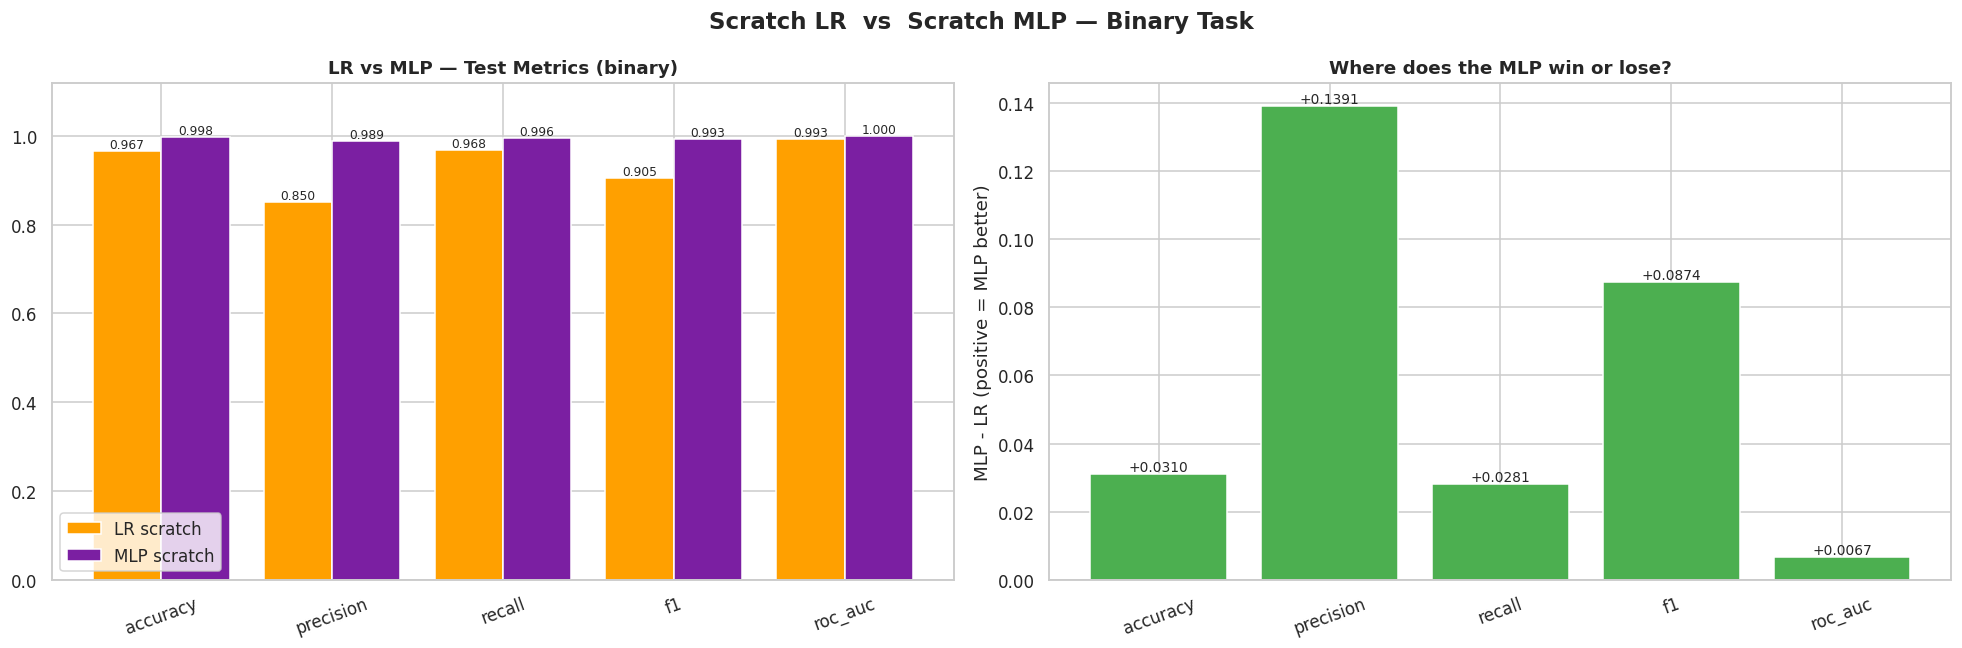


  Classification report (winning MLP):
              precision    recall  f1-score   support

      BENIGN     0.9992    0.9978    0.9985    429677
      ATTACK     0.9892    0.9961    0.9926     85176

    accuracy                         0.9975    514853
   macro avg     0.9942    0.9970    0.9956    514853
weighted avg     0.9976    0.9975    0.9975    514853

              precision    recall  f1-score   support

      BENIGN     0.9992    0.9978    0.9985    429677
      ATTACK     0.9892    0.9961    0.9926     85176

    accuracy                         0.9975    514853
   macro avg     0.9942    0.9970    0.9956    514853
weighted avg     0.9976    0.9975    0.9975    514853



In [9]:
# LR baseline numbers (from the LR-binary notebook, class-weighting model)
lr_metrics = {
    'accuracy':  0.9665,
    'precision': 0.8501,
    'recall':    0.9680,
    'f1':        0.9052,
    'roc_auc':   0.9932,
}

# pick the better MLP strategy
if metrics_B['f1'] > metrics_A['f1']:
    mlp_metrics, mlp_strategy = metrics_B, 'B_smote'
    final_model, final_pred, final_prob = mlp_B, pred_B, prob_B
else:
    mlp_metrics, mlp_strategy = metrics_A, 'A_class_weight'
    final_model, final_pred, final_prob = mlp_A, pred_A, prob_A

vs_df = pd.DataFrame({'LR_scratch': lr_metrics, 'MLP_scratch': mlp_metrics})
vs_df['delta_MLP_minus_LR'] = vs_df['MLP_scratch'] - vs_df['LR_scratch']

_log('')
_log('── SECTION 7 : MLP vs LR (HEADLINE) ───────────────────────')
_log(f'  LR baseline  : class-weighting model from Modeling_Binary.ipynb')
_log(f'  MLP entry    : strategy {mlp_strategy}  (winner of Section 6)')
_log('')
_log(vs_df.to_string())
display(vs_df)
_log('')
_log(f'  F1 delta  : {vs_df.loc["f1", "delta_MLP_minus_LR"]:+.4f}')
_log(f'  AUC delta : {vs_df.loc["roc_auc", "delta_MLP_minus_LR"]:+.4f}')

# headline visual
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
xx = np.arange(len(metric_names))
ax = axes[0]
ax.bar(xx - 0.2, [lr_metrics[m]  for m in metric_names], 0.4,
       label='LR scratch',  color='#FFA000')
ax.bar(xx + 0.2, [mlp_metrics[m] for m in metric_names], 0.4,
       label='MLP scratch', color='#7B1FA2')
ax.set_xticks(xx); ax.set_xticklabels(metric_names, rotation=20)
ax.set_ylim(0, 1.12)
ax.set_title('LR vs MLP — Test Metrics (binary)', fontweight='bold')
ax.legend()
for i, m in enumerate(metric_names):
    ax.text(i - 0.2, lr_metrics[m],  f'{lr_metrics[m]:.3f}',  ha='center', va='bottom', fontsize=8)
    ax.text(i + 0.2, mlp_metrics[m], f'{mlp_metrics[m]:.3f}', ha='center', va='bottom', fontsize=8)

# deltas
ax = axes[1]
deltas = [mlp_metrics[m] - lr_metrics[m] for m in metric_names]
colors = ['#4CAF50' if d > 0 else '#F44336' for d in deltas]
ax.bar(metric_names, deltas, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticklabels(metric_names, rotation=20)
ax.set_ylabel('MLP - LR (positive = MLP better)')
ax.set_title('Where does the MLP win or lose?', fontweight='bold')
for i, d in enumerate(deltas):
    ax.text(i, d, f'{d:+.4f}', ha='center', va='bottom' if d >= 0 else 'top', fontsize=9)

plt.suptitle('Scratch LR  vs  Scratch MLP — Binary Task',
             fontsize=15, fontweight='bold')
plt.tight_layout()
_savefig('04_lr_vs_mlp.png', fig)
plt.show()

# final classification report on the winning MLP
report = classification_report(y_test, final_pred, target_names=['BENIGN', 'ATTACK'], digits=4)
_log('')
_log('  Classification report (winning MLP):')
_log(report)
print(report)

## 8. Save Models, Metrics & Report

In [10]:
# save BOTH MLP weights — pure numpy arrays + config
p1 = os.path.join(OUT_DIR, 'mlp_scratch_binary_A_classweight.npz')
np.savez(p1, **mlp_A.params, features=np.array(selected_features),
         hidden_sizes=np.array(best_hs), lr=best_lr, dropout=best_drop,
         lambda_=best_lam, epochs=FINAL_EPOCHS, batch_size=BATCH_SIZE,
         strategy='A_class_weight')

p2 = os.path.join(OUT_DIR, 'mlp_scratch_binary_B_smote.npz')
np.savez(p2, **mlp_B.params, features=np.array(selected_features),
         hidden_sizes=np.array(best_hs), lr=best_lr, dropout=best_drop,
         lambda_=best_lam, epochs=FINAL_EPOCHS, batch_size=BATCH_SIZE,
         strategy='B_smote')

p3 = os.path.join(OUT_DIR, 'gridsearch_results_mlp.csv')
results_df.to_csv(p3, index=False)

p4 = os.path.join(OUT_DIR, 'smote_vs_classweight_comparison_mlp.csv')
cmp_df.to_csv(p4)

p5 = os.path.join(OUT_DIR, 'lr_vs_mlp_comparison.csv')
vs_df.to_csv(p5)

p6 = os.path.join(OUT_DIR, 'final_metrics_mlp.json')
with open(p6, 'w') as f:
    json.dump({
        'model': 'MLPScratch',
        'task': 'binary',
        'architecture': {'input_dim': n_features, 'hidden_sizes': list(best_hs),
                         'output_dim': 1, 'activation': 'ReLU', 'output_activation': 'sigmoid'},
        'best_hyperparameters': {'lr': best_lr, 'dropout': best_drop,
                                 'lambda_': best_lam, 'epochs': FINAL_EPOCHS,
                                 'batch_size': BATCH_SIZE},
        'strategy_A_class_weight': metrics_A,
        'strategy_B_smote':        metrics_B,
        'mlp_winning_strategy':    mlp_strategy,
        'lr_scratch_baseline':     lr_metrics,
        'mlp_vs_lr_delta':         {m: mlp_metrics[m] - lr_metrics[m] for m in lr_metrics},
    }, f, indent=2)

_log('')
_log('── SECTION 8 : FILES SAVED ────────────────────────────────')
for p in [p1, p2, p3, p4, p5, p6]:
    _log(f'  {os.path.basename(p)}')
    print(f'  {os.path.basename(p)}')


── SECTION 8 : FILES SAVED ────────────────────────────────
  mlp_scratch_binary_A_classweight.npz
  mlp_scratch_binary_A_classweight.npz
  mlp_scratch_binary_B_smote.npz
  mlp_scratch_binary_B_smote.npz
  gridsearch_results_mlp.csv
  gridsearch_results_mlp.csv
  smote_vs_classweight_comparison_mlp.csv
  smote_vs_classweight_comparison_mlp.csv
  lr_vs_mlp_comparison.csv
  lr_vs_mlp_comparison.csv
  final_metrics_mlp.json
  final_metrics_mlp.json


In [11]:
_log('')
_log('=' * 70)
_log('SUMMARY  --  BINARY MODELLING (MLP from scratch)')
_log('=' * 70)
_log(f'  Architecture     : [{n_features} -> {best_hs[0]} -> {best_hs[1]} -> 1]')
_log(f'  Parameter count  : {final_model.n_params():,}')
_log(f'  Activation       : ReLU (hidden) + sigmoid (output)')
_log(f'  Best hyperparams : lr={best_lr}, dropout={best_drop}, lambda={best_lam}')
_log('')
_log('  IMBALANCE STRATEGY COMPARISON (test set):')
_log(f'    {"metric":<12} {"A class-weight":>16} {"B SMOTE":>16}')
for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    _log(f'    {m:<12} {metrics_A[m]:>16.4f} {metrics_B[m]:>16.4f}')
_log(f'  MLP winning strategy : {mlp_strategy}')
_log('')
_log('  SCRATCH-LR vs SCRATCH-MLP (test set):')
_log(f'    {"metric":<12} {"LR":>10} {"MLP":>10} {"delta":>10}')
for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    d = mlp_metrics[m] - lr_metrics[m]
    _log(f'    {m:<12} {lr_metrics[m]:>10.4f} {mlp_metrics[m]:>10.4f} {d:>+10.4f}')
_log('')
_log('  This is scratch-model #2. Both "at least 2 from-scratch" requirements are met.')
_log('  Next: library baselines (Random Forest, XGBoost) and multi-class MLP.')

FIGURE_INDEX = [
    ('01_smoke_test.png',           'Smoke test: from-scratch MLP learns'),
    ('02_grid_search.png',          'Grid search results across architectures/dropout/lr'),
    ('03_smote_vs_classweight.png', 'SMOTE vs class-weighting -- full side-by-side'),
    ('04_lr_vs_mlp.png',            'LR scratch vs MLP scratch -- headline comparison'),
]
_log('')
_log('  Figures:')
for fname, desc in FIGURE_INDEX:
    _log(f'    {fname:<32} {desc}')

write_report()

print('\n' + '=' * 55)
print('BINARY MLP COMPLETE -- Multi-Layer Perceptron (scratch)')
print('=' * 55)
print(f'  Best architecture     : {best_hs}')
print(f'  MLP winning strategy  : {mlp_strategy}')
print(f'  MLP test F1           : {mlp_metrics["f1"]:.4f}   (LR was 0.9052)')
print(f'  MLP test ROC-AUC      : {mlp_metrics["roc_auc"]:.4f}   (LR was 0.9932)')
print(f'  Report  -> {OUT_DIR}/Modeling_Binary_MLP_Report.txt')
print(f'  Figures -> {FIGURES_DIR}/  ({len(FIGURE_INDEX)} figures)')


SUMMARY  --  BINARY MODELLING (MLP from scratch)
  Architecture     : [47 -> 256 -> 128 -> 1]
  Parameter count  : 45,313
  Activation       : ReLU (hidden) + sigmoid (output)
  Best hyperparams : lr=0.05, dropout=0.0, lambda=0.0

  IMBALANCE STRATEGY COMPARISON (test set):
    metric         A class-weight          B SMOTE
    accuracy               0.9965           0.9975
    precision              0.9823           0.9892
    recall                 0.9966           0.9961
    f1                     0.9894           0.9926
    roc_auc                0.9999           0.9999
  MLP winning strategy : B_smote

  SCRATCH-LR vs SCRATCH-MLP (test set):
    metric               LR        MLP      delta
    accuracy         0.9665     0.9975    +0.0310
    precision        0.8501     0.9892    +0.1391
    recall           0.9680     0.9961    +0.0281
    f1               0.9052     0.9926    +0.0874
    roc_auc          0.9932     0.9999    +0.0067

  This is scratch-model #2. Both "at least 